# Rosenstock et al.(2017) replication


Here we replicate Rosenstock et al. (2017) results, which consists in some robustness test for Zollman's (2010) results. They assess how the complete graph and the cycle graph perform as the objective probabilities of the correct theory, the number of pulls per step and the number of agents vary.
We start by importing the pacages and the model

In [2]:
import mesa
from mesa.discrete_space import Network, FixedAgent, CellCollection
import numpy as np
import networkx as nx
import pandas as pd
import seaborn as sns



###                 AGENTS                  ###
class Scientist(FixedAgent):

    def __init__(self, model, cell, a_objective, b_objective, max_priors, theory_threshold, inertia, step_pulls):
        super().__init__(model)
        self.cell = cell
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.max_priors = max_priors
        self.theory_threshold = theory_threshold
        self.inertia = inertia
        self.inertia_counter = 0
        self.step_pulls = step_pulls

        #Prior beliefs of each agent
        epsilon = .000000000000000000001
        self.priors = {
        "a_alpha": self.random.uniform(epsilon, self.max_priors),
        "a_beta": self.random.uniform(epsilon, self.max_priors),
        "b_alpha": self.random.uniform(epsilon, self.max_priors),
        "b_beta": self.random.uniform(epsilon, self.max_priors)
        }

        #Define whether the agents prefers to pull the A or B lever as it's state
        if self.a_expectations() > self.b_expectations():
            self.state = "a"
        else:
            self.state = "b"
        
        #Define the level of theory threshold of the agent
        if self.theory_threshold == True: 
            self.theory_threshold = 0.1
        else: self.theory_threshold = 0

        self.dynamic_counter = 0
        
        self.experiment_result = (0, 0, 0)
        

    #Funcions for calculating expectations for each hypotheses
    def a_expectations(self):
        a_exp = self.priors["a_alpha"] / (self.priors ["a_alpha"] + self.priors ["a_beta"])
        return a_exp

    def b_expectations(self):
        b_exp = self.priors["b_alpha"] / (self.priors ["b_alpha"] + self.priors ["b_beta"])
        return b_exp
    
    #Research behaviour: performing experiments
    def research(self):

        pull, success, trial = self.experiment_result

        #Choose action based of belief
        if self.state == "a":
            pull = 1
            current_objective_prob = self.a_objective
        else:
            pull = 2
            current_objective_prob = self.b_objective
        
        #Performing experiment (sampling from a binomial distribution)
        success = self.rng.binomial(n=self.step_pulls, p=current_objective_prob)
        
        trial = self.step_pulls

        self.experiment_result = (pull, success, trial)
        
        return self.experiment_result

    #Update behaviour: updating expectations based non experimental results
    def update(self):
        # Update beliefs based on OWN results
        pull, success, trial = self.experiment_result

        if pull == 1:
            self.priors["a_alpha"] += success
            self.priors["a_beta"] += trial - success
        else:
            self.priors["b_alpha"] += success
            self.priors["b_beta"] += trial - success

        #Update beliefs based on NEIGHBORS results
        for neighbor in self.cell.neighborhood.agents: 
            
            pull, success, trial = neighbor.experiment_result

            if pull == 1:
                self.priors["a_alpha"] += success
                self.priors["a_beta"] += trial - success
            else:
                self.priors["b_alpha"] += success
                self.priors["b_beta"] += trial - success
            
        #Updating preferences for experimentations (include theory_threshold and inertia)    
        if self.state == "a":
            if (self.a_expectations() + self.theory_threshold) > self.b_expectations():
                self.state = "a"
                self.inertia_counter = 0
            else:
                self.inertia_counter += 1
                if self.inertia_counter >= self.inertia:
                    self.state = "b"
        
        else:
            if (self.b_expectations() + self.theory_threshold) > self.a_expectations():
                self.state = "b"
                self.inertia_counter = 0
            else:
                self.inertia_counter += 1
                if self.inertia_counter >= self.inertia:
                    self.state = "a"
    
    def update_objectives(self):
        """Slightley modify the objective values to increase the one of the correct theory and diminish the one of the incorrect every 100 rounds"""
        if self.dynamic_counter < 100:
            self.dynamic_counter += 1
        else:
            self.dynamic_counter = 0
            self.a_objective += (1- self.a_objective) / 1000
            self.b_objective += (0- self.b_objective) / 1000
        
    def critical_interaction(self):
        """Slightly modify the objective values if neighbors provide more covincing evidence for the competing hypothesis"""
        pull, success, trial = self.experiment_result

        for neighbor in self.cell.neighborhood.agents: 
            neigh_pull, neigh_success, neigh_trial = neighbor.experiment_result

            if pull == 1:
                if neigh_pull != pull and neigh_success / neigh_trial > self.b_expectations():
                    self.a_objective += (1- self.a_objective) / 1000

            if pull == 2:
                if neigh_pull != pull and neigh_success / neigh_trial > self.a_expectations():
                    self.b_objective += (0 -self.b_objective) / 1000
    
    def clean_results(self):
        self.experiment_result = (0, 0, 0)
            
        

    
###                 MODEL                   ####
def convergence_round(model):
    if model.consensus_round == None:
        return "No consensus"
    else: return model.consensus_round

def correct_convergence(model):
    if sum(1 for a in model.agents if a.state == "a") == model.num_agents:
        return True
    else: return False

class Bandit(mesa.Model):
    """Model"""

    def __init__(
            self, 
            n=10,
            a_objective = .5, 
            b_objective = .499, 
            max_priors = 4,
            graph = "complete",
            theory_threshold = False,
            step_pulls = 1000,
            dynamic = False,
            criticism = False,
            inertia = 0,
            seed = None
                    ):

        super().__init__(seed=seed)
        self.num_agents = n
        self.a_objective = a_objective
        self.b_objective = b_objective
        self.theory_threshold = theory_threshold
        self.step_pulls = step_pulls
        self.dynamic = dynamic
        self.criticism = criticism
        #Defining the graph type
        if graph == "complete":
            self.grid = Network(nx.complete_graph(n), random=self.random)
        elif graph == "wheel":
            self.grid = Network(nx.wheel_graph(n), random=self.random)
        elif graph == "cycle":
            self.grid = Network(nx.cycle_graph(n), random=self.random)
        else : print("Uknown network type: please use ['complete', 'wheel', 'cycle']")
        # Create agents
        Scientist.create_agents(
            model=self, n=n, cell=list(self.grid.all_cells.cells), a_objective = self.a_objective, b_objective = self.b_objective, max_priors = max_priors, theory_threshold = theory_threshold, inertia = inertia, step_pulls = step_pulls)
    
        # Instantiate DataCollector
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Convergence Round": convergence_round,
                "Correct Convergence": correct_convergence    
            }
        )

        self.round_counter = 0
        self.consensus_round = None
        self.check_previous_conv = 0


    def check_convergence(self):
        """Checks whether all agents pursue the same hypothesis"""
        
        if sum(1 for a in self.agents if a.state == "a") == self.num_agents:
            if self.consensus_round != None and self.check_previous_conv != 1:
                self.consensus_round = None
            self.check_previous_conv = 1
            return 1
        if sum(1 for a in self.agents if a.state == "b") == self.num_agents:
            if self.consensus_round != None and self.check_previous_conv != 2:
                self.consensus_round = None
            self.check_previous_conv = 2
            return 2
        else:
            self.consensus_round = None 
            self.check_previous_conv = 0
            return 0
    
    def get_convergence_round(self):
        """Get the round in which agents converged"""
        if (self.check_convergence() == 1 or self.check_convergence() == 2) and self.consensus_round == None:
            self.consensus_round = self.round_counter
        

    def step(self):
        """Advance the model by one step."""
        self.datacollector.collect(self)
               
        self.agents.do("research")

        if self.dynamic == True:
            self.agents.do("update_objectives")
        
        if self.criticism == True:
            self.agents.do("critical_interaction")
        
        self.agents.do("update")
        self.agents.do("clean_results")

        self.round_counter += 1
        self.check_convergence()
        self.get_convergence_round()
        


We start by checking how results change if we increase the objective probability of the correct hypothesis in the range from 0.501 to 0.6. The parameters of the model are specified as in Rosenstock et al.(2017) original paper. We run 10000 simulation for each comination of parameters for 3000 steps.

  0%|          | 0/22000 [00:00<?, ?it/s]

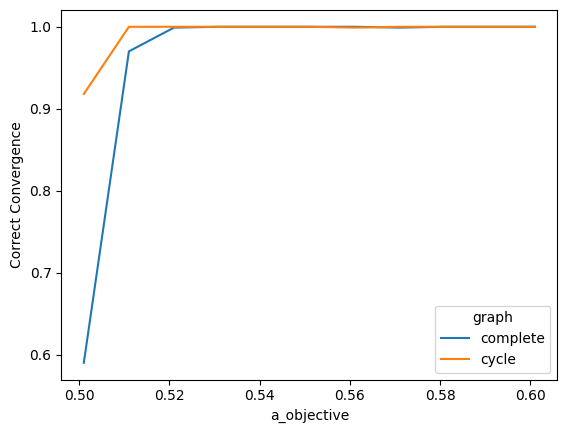

In [2]:

parameters_batch_run = {
        "n" : 10,
        "a_objective" : np.arange(.501, .610, .010), 
        "b_objective" : .5, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : False,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=3000
)

batch_run_results_df = pd.DataFrame(batch_run_results)

g = sns.lineplot(data=batch_run_results_df, x="a_objective", y="Correct Convergence", hue="graph", errorbar=None)

Here we see that as the difference between the objective probability of A and B dimishes, the two networks equally converge on the correct hypothesis every time.

Now we see the results for varying the numbers of pulls per step from 1000 to 9000 with steps of 1000. For each combination of parameters we run 1000 simulations for 2000 steps. NB differently from Zollman's setting, here the difference from the objective probability of A and B is .1

  0%|          | 0/18000 [00:00<?, ?it/s]

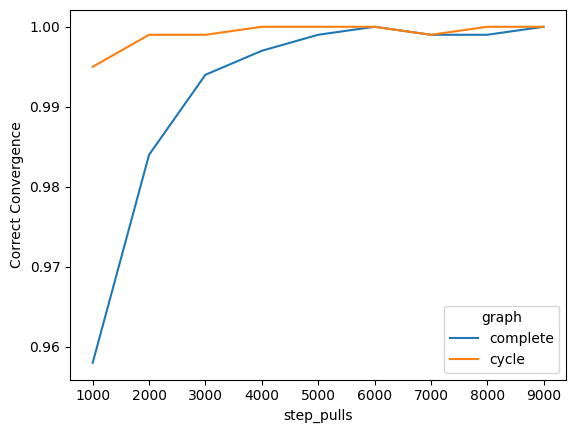

In [ ]:

parameters_batch_run = {
        "n" : 10,
        "a_objective" : .51, 
        "b_objective" : .5, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : range(1000, 10000, 1000),
        "dynamic" : False,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=2000
)

batch_run_results_df = pd.DataFrame(batch_run_results)

g = sns.lineplot(data=batch_run_results_df, x="step_pulls", y="Correct Convergence", hue="graph", errorbar=None)

Here we can see that as the number of pulls per step increase, so that experimental information more closely reflect the objective porbabilities, the two networks offer almost instinguishable performances.

Now we check as the probability of correct convergens for the complete graph and the cycle graph vary as the number of agents vary from 10, 20, 40, 80. For each combination of parameters we run 1000 iterations for 3000 steps. NB to match Rosebstock et al. model, we used prior beliefs of 1/1, modifying epsilon

  0%|          | 0/8000 [00:00<?, ?it/s]

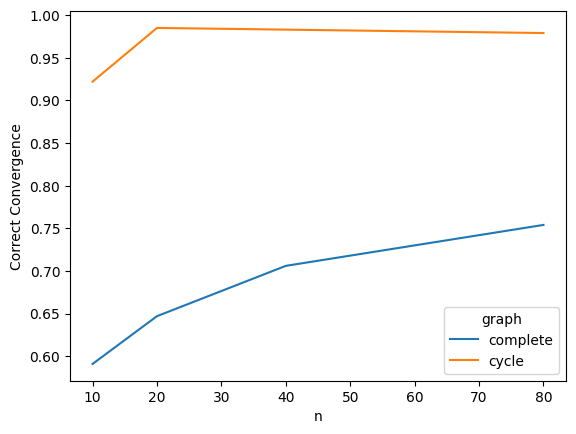

In [ ]:

parameters_batch_run = {
        "n" : [10, 20, 40, 80],
        "a_objective" : .501, 
        "b_objective" : .5, 
        "max_priors" : 4,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : False,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=4000
)

batch_run_results_df = pd.DataFrame(batch_run_results)

g = sns.lineplot(data=batch_run_results_df, x="n", y="Correct Convergence", hue="graph", errorbar=None)

Here we found different results: the complete graph does not converge on the correct theory as often as it should be. I'll investiate further to check wheter there are some differences in parameters or there are some problems with the model itself

However we also check the speed of convergence of the two types of graphs

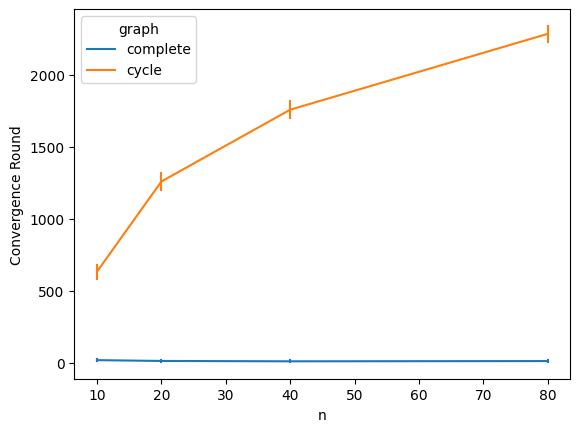

In [ ]:
g = sns.lineplot(data=batch_run_results_df, x="n", y="Convergence Round", hue="graph", err_style="bars")

Here convergence times look similar to the ones reported in the paper.

Since the original model has a differen way of addressing prior belief, we try to replicate the results using a different parameter for max priors

  0%|          | 0/6000 [00:00<?, ?it/s]

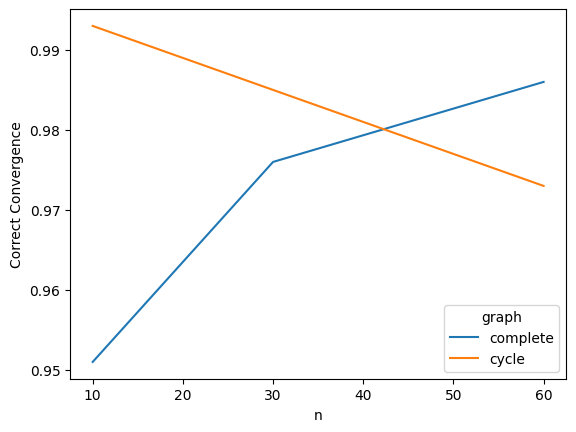

In [6]:

parameters_batch_run = {
        "n" : [10, 30, 60],
        "a_objective" : .501, 
        "b_objective" : .5, 
        "max_priors" : 1000,
        "graph" : ["complete", "cycle"],
        "theory_threshold" : False,
        "step_pulls" : 1000,
        "dynamic" : False,
        "criticism" : False,
        "inertia" : 0,
        "seed" : None
    }

batch_run_results = mesa.batch_run(
    Bandit,
    parameters= parameters_batch_run,
    iterations=1000,
    max_steps=4000
)

batch_run_results_df = pd.DataFrame(batch_run_results)

g = sns.lineplot(data=batch_run_results_df, x="n", y="Correct Convergence", hue="graph", errorbar=None)

This times results are compatible with the one of the original paper, hypothesising that the cycle had too little step to always converge for larger n. To further investigate we check how many interaction did not result in consensus.

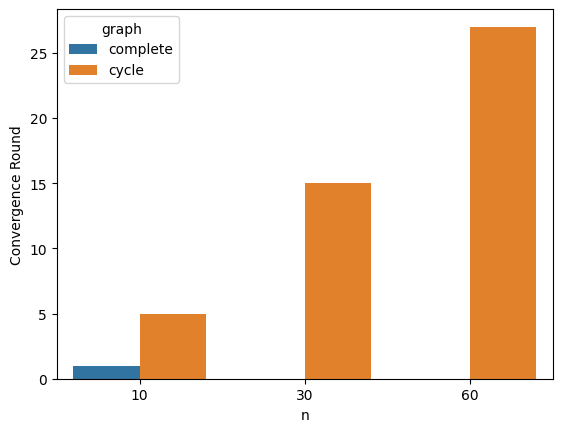

In [23]:
no_consensus = batch_run_results_df[batch_run_results_df["Convergence Round"] == "No consensus"]
no_consensus = no_consensus.groupby(["n", "graph"]).agg({"Convergence Round" : "count"})
no_consensus
g = sns.barplot(no_consensus, x="n", y="Convergence Round", hue="graph", errorbar=None)

Probably the cycle had too little steps to converge for larger n, giving us confidence that for a larger number of steps the results would be similar to the original paper

Let's also re-check the convergence round

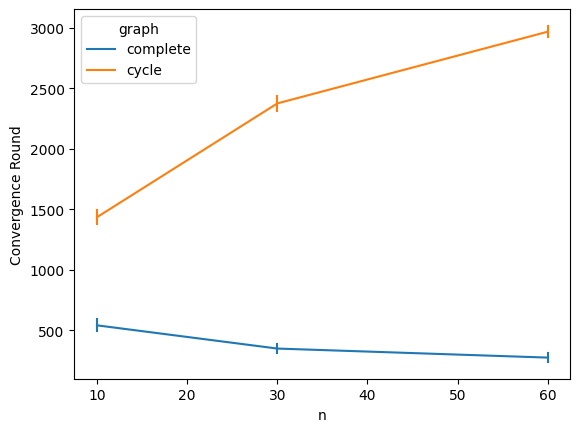

In [25]:
consensus_filtered = batch_run_results_df[batch_run_results_df["Convergence Round"] != "No consensus"]
g = sns.lineplot(data=consensus_filtered, x="n", y="Convergence Round", hue="graph", err_style="bars")

This time both graphs were slower in reaching consensus, but the main patter remained the same